# Setup

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
from dateutil.parser import parse
from scipy.optimize import minimize, Bounds
from numpy.linalg import norm
import math
import matplotlib.pyplot as plt

In [2]:
LSTM_Predicted_Prices = pd.read_csv('Predicted_LSTM_Prices.csv')
LSTM_Predicted_Prices['Date'] = pd.to_datetime(LSTM_Predicted_Prices['Date'])
LSTM_Predicted_Prices.set_index('Date', inplace=True)

LSTM_Actual_Prices = pd.read_csv('Actual_LSTM_Prices.csv')  
LSTM_Actual_Prices['Date'] = pd.to_datetime(LSTM_Actual_Prices['Date'])
LSTM_Actual_Prices.set_index('Date', inplace=True)

In [3]:
LSTM_Predicted_Prices.shape, LSTM_Actual_Prices.shape

((380, 20), (380, 20))

In [4]:
LSTM_Predicted_Returns = LSTM_Predicted_Prices.apply(lambda x: np.log(x) - np.log(x.shift(60))).iloc[60:]
LSTM_Actual_Returns = LSTM_Actual_Prices.apply(lambda x: np.log(x) - np.log(x.shift(60))).iloc[60:]

In [5]:
LSTM_Actual_Returns.shape

(320, 20)

# Helper Function

In [6]:
#Mean Returns function
def mean_returns(df, length): 
  mu = df.sum(axis = 0)/length
  return mu

In [7]:
def monthdelta(date, delta):
    m, y = (date.month+delta) % 12, date.year + ((date.month)+delta-1) // 12
    if not m: m = 12
    d = min(date.day, [31,
        29 if y%4==0 and not y%400==0 else 28,31,30,31,30,31,31,30,31,30,31][m-1])
    new_date = (date.replace(day=d,month=m, year=y))
    return parse(new_date.strftime('%Y-%m-%d'))

def windowGenerator (dataframe, lookback, horizon,
                    step, cummulative = False):

    if cummulative:
        c = lookback
        step = horizon
        
    initial = min(dataframe.index)
    windows = []
    horizons = []

    while initial <= monthdelta(max(dataframe.index), -lookback):
        windowStart = initial
        windowEnd = monthdelta(windowStart, lookback)
        if cummulative:
            windowStart = min(dataframe.index)
            windowEnd = monthdelta(windowStart, c) + timedelta(days=1)
            c += horizon
        horizonStart = windowEnd + timedelta(days=1)
        horizonEnd = monthdelta(horizonStart, horizon)

        lookbackWindow = dataframe[windowStart:windowEnd]
        horizonWindow = dataframe[horizonStart:horizonEnd]

        windows.append(lookbackWindow)
        horizons.append(horizonWindow)

        initial = monthdelta(initial, step)

    return windows, horizons

In [8]:
import pandas as pd
import numpy as np

def window_generator(dataframe, lookback, horizon, frequency, mode='fixed'):
    windows = []
    horizons = []
    
    df = dataframe.sort_index()
    start_date = df.index[0]
    end_date = df.index[-1]
    
    current_date = start_date

    if mode == 'fixed':
        while current_date + lookback + horizon <= end_date:
            window_start = current_date
            window_end = current_date + lookback
            horizon_start = window_end
            horizon_end = window_end + horizon
            
            windows.append(df.loc[window_start:window_end])
            horizons.append(df.loc[horizon_start:horizon_end])
            
            current_date = current_date + frequency

    elif mode == 'expanding':
        while current_date + horizon <= end_date:
            window_start = start_date
            window_end = current_date
            horizon_start = current_date
            horizon_end = current_date + horizon
            
            windows.append(df.loc[window_start:window_end])
            horizons.append(df.loc[horizon_start:horizon_end])
            
            current_date = current_date + frequency

    elif mode == 'adaptive':
        threshold = 0.05  # Set an arbitrary volatility threshold
        fixed_vol_window = pd.Timedelta(days=30)  # Use the last 30 days to measure volatility
        
        while current_date + horizon <= end_date:
            # Determine volatility over the fixed past window
            vol_window = df.loc[max(start_date, current_date - fixed_vol_window):current_date]
            volatility = vol_window.std().mean()  # average volatility across features
            
            # If volatility is high, use a shorter lookback; otherwise, use the default.
            if volatility > threshold:
                adaptive_lookback = pd.Timedelta(days=60)
            else:
                adaptive_lookback = lookback
            
            window_start = current_date - adaptive_lookback
            if window_start < start_date:
                window_start = start_date
            window_end = current_date
            horizon_start = current_date
            horizon_end = current_date + horizon
            
            windows.append(df.loc[window_start:window_end])
            horizons.append(df.loc[horizon_start:horizon_end])
            
            current_date = current_date + frequency
    else:
        raise ValueError("Unsupported mode. Use 'fixed', 'expanding', or 'adaptive'.")
    
    return windows, horizons

# Example usage:
# Suppose we want to align with the LSTM training period (150 days) and the 60-day shift for returns, but we want to rebalance weekly:
lookback_offset = pd.DateOffset(days=150)   # Use 150 days lookback (or adjust as desired)
horizon_offset  = pd.DateOffset(days=60)      # Use 60 days horizon (or adjust as needed)
frequency_offset = pd.DateOffset(weeks=1)     # Weekly rebalancing (could use pd.DateOffset(weeks=2) for bi-weekly)

# For predicted returns:
LSTM_pred_windows, LSTM_pred_horizons = window_generator(
    LSTM_Predicted_Returns, 
    lookback=lookback_offset, 
    horizon=horizon_offset, 
    frequency=frequency_offset, 
    mode='fixed'  # Try 'expanding' or 'adaptive' as alternatives
)

# For actual returns:
LSTM_act_windows, LSTM_act_horizons = window_generator(
    LSTM_Actual_Returns, 
    lookback=lookback_offset, 
    horizon=horizon_offset, 
    frequency=frequency_offset, 
    mode='fixed'
)

print("Number of prediction windows:", len(LSTM_pred_windows))
print("Number of actual windows:", len(LSTM_act_windows))

Number of prediction windows: 16
Number of actual windows: 16


In [9]:
def actual_return(actual_returns, w):
  actual_returns = actual_returns
  mean_return = mean_returns(actual_returns, actual_returns.shape[0])
  actual_covariance = actual_returns.cov()

  portfolio_returns = mean_return.T.dot(w)
  portfolio_variance = w.T.dot(actual_covariance).dot(w)
  return portfolio_returns, portfolio_variance


def scipy_opt(predicted_returns, actual_returns, lam1, lam2):
  mean_return = mean_returns(predicted_returns, predicted_returns.shape[0])
  predicted_covariance = predicted_returns.cov()
  
  def f(w):
    return -(mean_return.T.dot(w) - lam1*(w.T.dot(predicted_covariance).dot(w)) + lam2*norm(w, ord=1))

  opt_bounds = Bounds(0, 1)

  def h(w):
    return sum(w) - 1

  #Constraints Dictionary
  cons = ({
      'type' : 'eq',
      'fun' : lambda w: h(w)
  })

  #Solver
  sol = minimize(f,
                 x0 = np.ones(mean_return.shape[0]),
                 constraints = cons,
                 bounds = opt_bounds,
                 options = {'disp': False},
                 tol=10e-10)

  w = sol.x
  predicted_portfolio_returns = w.dot(mean_return)
  portfolio_STD = w.T.dot(predicted_covariance).dot(w)
  
  portfolio_actual_returns, portfolio_actual_variance = actual_return(actual_returns, w)
    
  # Correct calculation using the square root of the variance to get the standard deviation.
  sharpe_ratio = portfolio_actual_returns / np.sqrt(portfolio_actual_variance)

  ret_dict = {'weights' : w,
              'predicted_returns' : predicted_portfolio_returns,
              'predicted_variance' : portfolio_STD,
              'actual_returns' : portfolio_actual_returns,
              'actual_variance' : portfolio_actual_variance,
              'sharpe_ratio': sharpe_ratio}
  
  return ret_dict

# Optimization

In [ ]:
# LSTM_pred_windows, LSTM_pred_horizons = windowGenerator(LSTM_Predicted_Returns, lookback=2, horizon=1, step=1)
# LSTM_act_windows, LSTM_act_horizons = windowGenerator(LSTM_Actual_Returns, lookback=2, horizon=1, step=1)

In [10]:
len(LSTM_pred_horizons)

16

In [11]:
scipy_returns = []
scipy_variance = []
scipy_SR = []

# Loop over all available horizon windows (since we have 9 windows)
for i in range(len(LSTM_act_horizons)):
    results = scipy_opt(LSTM_pred_horizons[i], LSTM_act_horizons[i], lam1=0.5, lam2=2)
    scipy_returns.append(results['actual_returns'])
    scipy_variance.append(results['actual_variance'])
    scipy_SR.append(results['sharpe_ratio'])
    print("Window " + str(i) + " complete")


Window 0 complete
Window 1 complete
Window 2 complete
Window 3 complete
Window 4 complete
Window 5 complete
Window 6 complete
Window 7 complete
Window 8 complete
Window 9 complete
Window 10 complete
Window 11 complete
Window 12 complete
Window 13 complete
Window 14 complete
Window 15 complete


In [22]:
results['weights']

array([9.28187947e-17, 5.03347793e-16, 3.36676337e-18, 1.00000000e+00,
       7.63278329e-17, 1.32731391e-16, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.95376924e-17,
       0.00000000e+00, 1.14491749e-16, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.06892384e-16, 0.00000000e+00, 4.56668007e-17])

In [12]:
timestamps = []
for i in range(len(LSTM_act_horizons)):
  time = LSTM_act_horizons[i].index[0]
  timestamps.append(time)
  
LSTM_Portfolio_Returns = pd.DataFrame(data = np.array([scipy_returns,scipy_variance,scipy_SR]).T, columns = ['Returns', 'Variance', 'Sharpe Ratio'], index=timestamps)

LSTM_Portfolio_Returns.to_csv('LSTM_Portfolio_Returns.csv')

In [13]:
timestamps 

[Timestamp('2024-06-16 00:00:00'),
 Timestamp('2024-06-23 00:00:00'),
 Timestamp('2024-06-30 00:00:00'),
 Timestamp('2024-07-07 00:00:00'),
 Timestamp('2024-07-14 00:00:00'),
 Timestamp('2024-07-21 00:00:00'),
 Timestamp('2024-07-28 00:00:00'),
 Timestamp('2024-08-04 00:00:00'),
 Timestamp('2024-08-11 00:00:00'),
 Timestamp('2024-08-18 00:00:00'),
 Timestamp('2024-08-25 00:00:00'),
 Timestamp('2024-09-01 00:00:00'),
 Timestamp('2024-09-08 00:00:00'),
 Timestamp('2024-09-15 00:00:00'),
 Timestamp('2024-09-22 00:00:00'),
 Timestamp('2024-09-29 00:00:00')]

In [14]:
LSTM_Portfolio_Returns

,Returns,Variance,Sharpe Ratio
2024-06-16,0.065508,0.001454,1.718119
2024-06-23,0.037774,0.006240,0.478197
2024-06-30,0.051059,0.012128,0.463626
2024-07-07,0.056591,0.010731,0.546286
2024-07-14,0.064809,0.008960,0.684677
2024-07-21,0.060404,0.009488,0.620129
2024-07-28,0.037974,0.010827,0.364956
2024-08-04,0.011475,0.008387,0.125301
2024-08-11,0.006759,0.003026,0.122870
2024-08-18,0.035528,0.001418,0.943572


# Diagnostics

In [15]:
LSTM_equity = [100]

#This is the calculation for the for seeing how much the portfolio grows
for i in range(1, len(scipy_returns)):
  LSTM_equity.append(LSTM_equity[i-1]* math.exp(scipy_returns[i]))

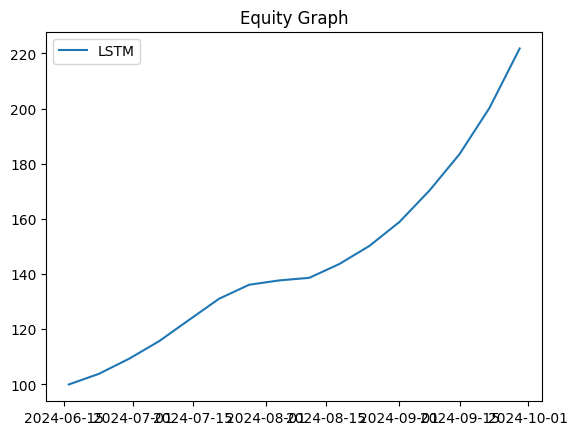

In [16]:
plt.plot(timestamps, LSTM_equity, label = "LSTM")
plt.title("Equity Graph")
plt.legend()
plt.show()

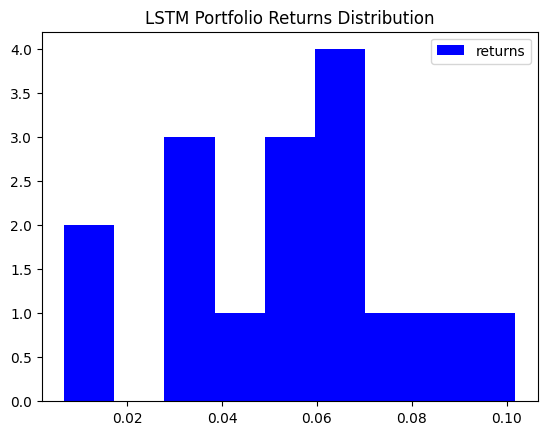

In [17]:
plt.hist(scipy_returns, bins = 9, label = 'returns', alpha = 1, color = 'blue') 
plt.title("LSTM Portfolio Returns Distribution")
plt.legend()
plt.show()

In [18]:
print("LSTM Ending Equity" , LSTM_equity[-1])

LSTM Ending Equity 221.81122826354175


In [19]:
def metrics(returns): 
  sharpe = returns.mean() / returns.std()
  annualized_sharpe = sharpe.item() / math.sqrt(252)

  stdev = returns.std() 
  annualized_vol = stdev.item() / math.sqrt(252)

  return {"Annualized Sharpe Ratio": annualized_sharpe,
          "Annualized Volatility": annualized_vol}

In [ ]:
# Annualized info for LSTM
metrics(np.array(scipy_returns))

{'Annualized Sharpe Ratio': 0.14018704153138184,
 'Annualized Volatility': 0.0015253233889842546}